## Import Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ( classification_report, confusion_matrix, 
                            accuracy_score, roc_auc_score, precision_recall_curve, f1_score,
                            precision_score, recall_score )
from sklearn.calibration import CalibratedClassifierCV

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

import optuna
import joblib
import json
import shap
shap.initjs()

## Load Data

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning

### Convert data types

In [6]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df.drop(columns=['customerID'],inplace=True)

In [11]:
df.duplicated().sum()

np.int64(22)

### Handing missing and duplicated values

In [12]:
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace = True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_6500\1129601867.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['MonthlyCharges'], inplace = True)


In [13]:
df.drop_duplicates(inplace=True)

## Data Preprocessing

In [14]:
df.replace('No internet service', 'No', inplace=True)
df.replace('No phone service', 'No', inplace=True)

In [15]:
def replace_yes_no(df, columns):
    
    for col in columns:
        df[col] = df[col].replace({'Yes': 1, 'No': 0})

columns_to_replace = [
    "Partner", "Dependents", "PhoneService",'MultipleLines', "OnlineSecurity", "OnlineBackup", 
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", 
    "PaperlessBilling", "Churn"
]

replace_yes_no(df, columns_to_replace)

C:\Users\DELL\AppData\Local\Temp\ipykernel_6500\732218029.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({'Yes': 1, 'No': 0})


In [16]:
nominal_cat_cols = ['InternetService','PaymentMethod']
ordinal_cat_cols = ['Contract']
num_cols = ['tenure','MonthlyCharges','TotalCharges']

preprocessor = ColumnTransformer(
    transformers=[
    ('nominal',OneHotEncoder(handle_unknown='ignore'),nominal_cat_cols),
    ('ordinal',OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']]),ordinal_cat_cols),
    ('scaler',StandardScaler(),num_cols)
],remainder='passthrough')

## Model Training

In [17]:
X = df.drop(columns=['Churn','gender'],axis=1)
y = df['Churn']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify=y)

In [19]:
print(X_train.shape)
print(y_train.shape)

(5616, 18)
(5616,)


In [20]:
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',SMOTETomek(random_state=42)),
    ('model', LogisticRegression(max_iter = 2000, random_state = 42, solver='liblinear'))
])

In [21]:
params={
        'model__C':[0.1,0.2,1,5,10],
        'model__penalty':['l1','l2']
       }

grid=GridSearchCV(estimator=pipe,
                  param_grid=params,
                  cv=5,
                  scoring='f1_macro')

grid.fit(X_train,y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('nominal',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['InternetService',
                                                                          'PaymentMethod']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['Month-to-month',
                                                                                                     'One '
                                                                                                     'year',
                                                                                                     'Two '
                                                                                                     'year']]),
                                                                         ['Contract']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges'])])),
                                       ('smote', SMOTETomek(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=2000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             param_grid={'model__C': [0.1, 0.2, 1, 5, 10],
                         'model__penalty': ['l1', 'l2']},
             scoring='f1_macro')

In [22]:
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:,1]
print('accuracy score : ',accuracy_score(y_test,y_pred))
print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print('ROC score : ',roc_auc_score(y_test,y_prob))

print('\n')
print('Classification report : \n',classification_report(y_test,y_pred))
print('Confusion matrix : \n ',confusion_matrix(y_test, y_pred))

accuracy score :  0.7451957295373666
Macro F1: 0.7126257501588302
Weighted F1: 0.758141091319956
ROC score :  0.8404961538061185


Classification report : 
               precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.51      0.77      0.62       372

    accuracy                           0.75      1405
   macro avg       0.71      0.75      0.71      1405
weighted avg       0.80      0.75      0.76      1405

Confusion matrix : 
  [[760 273]
 [ 85 287]]


## Using Optuna for hyperparameter tuning

In [53]:
!pip install optuna

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

def get_resampler(name):
    """Maps a resampler name to an actual instance."""
    if name == 'SMOTE':
        return SMOTE(random_state=42)
    elif name == 'SMOTETomek':
        return SMOTETomek(random_state=42)
    elif name == 'ADASYN':
        return ADASYN(random_state=42)
    else:
        raise ValueError(f'Unknown resampler: {name}')


def build_pipeline(model_name, params, resampler_name=None):
    """Builds the correct pipeline per model — imbalance strategy differs by model."""
    if model_name == 'random_forest':
        model = RandomForestClassifier(random_state=42, class_weight='balanced', **params)
        steps = [('preprocessor', preprocessor), ('model', model)]

    elif model_name == 'xgboost':
        model = XGBClassifier(
            random_state=42, scale_pos_weight=scale_pos_weight,
            eval_metric='logloss', **params
        )
        steps = [('preprocessor', preprocessor), ('model', model)]

    elif model_name == 'gradient_boosting':
        # GradientBoostingClassifier has no class_weight param, so a resampler is required
        model = GradientBoostingClassifier(random_state=42, **params)
        resampler = get_resampler(resampler_name)
        steps = [('preprocessor', preprocessor), ('smote', resampler), ('model', model)]

    else:
        raise ValueError(f'Unknown model_name: {model_name}')

    return Pipeline(steps)

In [24]:
def suggest_params(trial, model_name):
    """Search space per model."""
    if model_name == 'random_forest':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 700),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        }

    elif model_name == 'xgboost':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0, 0.5),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        }

    elif model_name == 'gradient_boosting':
        return {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 2, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            }

    else:
        raise ValueError(f'Unknown model_name: {model_name}')

In [25]:
def tune_model(model_name, X_train, y_train, n_trials=100, scoring='f1_macro'):
    """
    Runs an Optuna study for the given model and returns the best fitted pipeline.
    model_name: one of 'random_forest', 'xgboost', 'gradient_boosting'
    """
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    def objective(trial):
        params = suggest_params(trial, model_name)

        resampler_name = None
        if model_name == 'gradient_boosting':
            resampler_name = trial.suggest_categorical('resampler', ['SMOTE', 'SMOTETomek', 'ADASYN'])

        pipeline = build_pipeline(model_name, params, resampler_name=resampler_name)
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        return scores.mean()

    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', study_name=model_name, sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f'\n=== {model_name} ===')
    print('Best CV score :', study.best_value)
    print('Best params   :', study.best_params)

    # study.best_params now includes 'resampler' for GB — split it back out
    best_params = dict(study.best_params)
    best_resampler_name = best_params.pop('resampler', None)

    best_pipeline = build_pipeline(model_name, best_params, resampler_name=best_resampler_name)
    best_pipeline.fit(X_train, y_train)

    return best_pipeline, study

In [26]:
tuned_models = {}
studies = {}

for name in ['random_forest', 'xgboost', 'gradient_boosting']:
    tuned_models[name], studies[name] = tune_model(name, X_train, y_train, n_trials=100)

  0%|          | 0/100 [00:00<?, ?it/s]


=== random_forest ===
Best CV score : 0.7410588454462446
Best params   : {'n_estimators': 136, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'bootstrap': True}


  0%|          | 0/100 [00:00<?, ?it/s]


=== xgboost ===
Best CV score : 0.737333146454023
Best params   : {'n_estimators': 177, 'max_depth': 10, 'learning_rate': 0.010088167470570232, 'subsample': 0.6743851510072575, 'colsample_bytree': 0.6005733337178535, 'min_child_weight': 4, 'gamma': 0.047118545129787234, 'reg_alpha': 0.0033152971550478774, 'reg_lambda': 0.09222525074627515}


  0%|          | 0/100 [00:00<?, ?it/s]


=== gradient_boosting ===
Best CV score : 0.7475127640989896
Best params   : {'n_estimators': 171, 'max_depth': 2, 'learning_rate': 0.1462180282080443, 'subsample': 0.9464967779090728, 'min_samples_split': 4, 'min_samples_leaf': 3, 'resampler': 'SMOTETomek'}


In [27]:
for name, model in tuned_models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f'--- {name} ---')
    print('Accuracy :', accuracy_score(y_test, pred))
    print('Macro F1 :', f1_score(y_test, pred, average='macro'))
    print('ROC-AUC  :', roc_auc_score(y_test, proba))
    print(classification_report(y_test, pred))
    print(confusion_matrix(y_test, pred))
    print()

--- random_forest ---
Accuracy : 0.7708185053380783
Macro F1 : 0.730226595110316
ROC-AUC  : 0.840202094328035
              precision    recall  f1-score   support

           0       0.89      0.79      0.83      1033
           1       0.55      0.72      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

[[814 219]
 [103 269]]

--- xgboost ---
Accuracy : 0.7729537366548043
Macro F1 : 0.7352853451458103
ROC-AUC  : 0.8409970958373668
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1033
           1       0.55      0.75      0.64       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.74      1405
weighted avg       0.80      0.77      0.78      1405

[[808 225]
 [ 94 278]]

--- gradient_boosting ---
Accuracy : 0.7921708185053381
Macro F1 : 0.7404889379187

## Model Evaluation

In [28]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1_macro': f1_score(y_test, pred, average='macro'),
        'roc_auc': roc_auc_score(y_test, proba),
        'precision': precision_score(y_test,pred),
        'recall': recall_score(y_test, pred)
    }

all_models = {
    'logistic_regression': grid,
    'random_forest': tuned_models['random_forest'],
    'xgboost': tuned_models['xgboost'],
    'gradient_boosting': tuned_models['gradient_boosting'],
}

results = []
for name, model in all_models.items():
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

              model  accuracy  f1_macro  roc_auc  precision   recall
  gradient_boosting  0.792171  0.740489 0.842640   0.598522 0.653226
            xgboost  0.772954  0.735285 0.840997   0.552684 0.747312
      random_forest  0.770819  0.730227 0.840202   0.551230 0.723118
logistic_regression  0.745196  0.712626 0.840496   0.512500 0.771505


# Model Comparison and Final Model Selection

To identify the most suitable model for customer churn prediction, four machine learning algorithms were evaluated: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost. The models were compared using Accuracy, Macro F1-score, ROC-AUC, Precision, and Recall.

| Model               |   Accuracy |   Macro F1 |    ROC-AUC |  Precision |     Recall |
| ------------------- | ---------: | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression |     74.52% |     71.26% |     84.05% |     51.25% | **77.15%** |
| Random Forest       |     77.08% |     73.02% |     84.02% |     55.12% |     72.31% |
| XGBoost             |     77.30% |     73.53% |     84.10% |     55.27% | **74.73%** |
| Gradient Boosting   | **79.22%** | **74.05%** | **84.26%** | **59.85%** |     65.32% |

## Logistic Regression

Logistic Regression was used as the baseline model for binary classification. It achieved the highest Recall (77.15%), indicating that it successfully identified the largest proportion of customers who were likely to churn. However, it recorded the lowest Accuracy, Macro F1-score, and Precision among all evaluated models. This means that although the model detects more churning customers, it also produces a larger number of false-positive predictions and lacks the overall predictive capability of the ensemble-based approaches.

## Random Forest

Random Forest significantly improved the overall classification performance compared with Logistic Regression. It achieved an Accuracy of 77.08%, a Macro F1-score of 73.02%, a ROC-AUC of 84.02%, and a Recall of 72.31%. Compared with Logistic Regression, Random Forest provides a better balance between predictive accuracy and churn detection. However, its Recall is still lower than that of XGBoost, indicating that it misses more customers who are actually at risk of churning.

## Gradient Boosting

Gradient Boosting achieved the strongest overall predictive performance among all evaluated models. It recorded the highest Accuracy (79.22%), Macro F1-score (74.05%), ROC-AUC (84.26%), and Precision (59.85%). These results demonstrate excellent classification capability and a lower false-positive rate. However, its Recall (65.32%) is considerably lower than both Logistic Regression and XGBoost, meaning that it fails to identify a larger proportion of customers who are actually likely to churn. Since customer churn prediction prioritizes identifying at-risk customers, this lower Recall represents an important limitation despite its superior overall performance.

## XGBoost

XGBoost demonstrated the best balance between churn detection and overall model performance. It achieved an Accuracy of 77.30%, a Macro F1-score of 73.53%, a ROC-AUC of 84.10%, a Precision of 55.27%, and a Recall of 74.73%. Although its overall Accuracy is slightly lower than Gradient Boosting, it identifies substantially more customers who are likely to churn. Compared with Random Forest, XGBoost achieved higher Accuracy, higher Macro F1-score, higher ROC-AUC, and better Recall, making it a stronger overall model for the customer churn prediction task.

## Comparison

The comparison highlights the strengths of each model:

* **Logistic Regression** achieved the highest Recall but showed the weakest overall predictive performance.
* **Random Forest** provided balanced performance with improved Accuracy and Macro F1-score but detected fewer churning customers than XGBoost.
* **Gradient Boosting** achieved the highest Accuracy, Macro F1-score, ROC-AUC, and Precision, demonstrating the strongest general classification performance. However, its lower Recall means that it misses a larger number of customers who are actually at risk of churning.
* **XGBoost** offered the best compromise between churn detection and overall predictive performance. It maintained competitive Accuracy and ROC-AUC while achieving substantially higher Recall than both Random Forest and Gradient Boosting.

## Final Model Selection

Customer churn prediction is a business-critical classification problem where the cost of failing to identify a customer who is likely to churn (False Negative) is generally much higher than the cost of incorrectly identifying a loyal customer as a churner (False Positive). Therefore, **Recall is considered the primary evaluation metric**, while Accuracy, Macro F1-score, ROC-AUC, and Precision are used to evaluate the model's overall predictive performance.

Although **Gradient Boosting** achieved the highest Accuracy (79.22%), Macro F1-score (74.05%), ROC-AUC (84.26%), and Precision (59.85%), its Recall (65.32%) was considerably lower than XGBoost. This means that Gradient Boosting would fail to identify a larger number of customers who are actually at risk of churning, reducing its effectiveness for customer retention initiatives.

**XGBoost**, on the other hand, achieved a Recall of **74.73%**, which is significantly higher than both Random Forest (72.31%) and Gradient Boosting (65.32%), while maintaining competitive Accuracy (77.30%), Macro F1-score (73.53%), and ROC-AUC (84.10%). This demonstrates that XGBoost provides a more balanced trade-off between detecting customers who are likely to churn and maintaining strong overall predictive performance.

Therefore, **XGBoost was selected as the final model** 

In [29]:
best_xgb_pipeline = tuned_models['xgboost']

joblib.dump(best_xgb_pipeline, 'xgb_pipeline.pkl')

['xgb_pipeline.pkl']

In [30]:
scoring = ['accuracy', 'f1_macro', 'roc_auc']
cv_results = cross_validate(best_xgb_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f'{metric}: {scores.mean():.4f} ± {scores.std():.4f}')

accuracy: 0.7703 ± 0.0097
f1_macro: 0.7326 ± 0.0098
roc_auc: 0.8416 ± 0.0098


## Probability Calibration

In [31]:
calibrated_xgb = CalibratedClassifierCV(best_xgb_pipeline , method='isotonic', cv=5)
calibrated_xgb.fit(X_train, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('nominal',
                                                                                   OneHotEncoder(handle_unknown='ignore'),
                                                                                   ['InternetService',
                                                                                    'PaymentMethod']),
                                                                                  ('ordinal',
                                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                                               'One '
                                                                                                               'year',
                                                                                                               'Two '
                                                                                                               'year']]),
                                                                                   ['Contract']),
                                                                                  ('scaler',
                                                                                   StandardScaler(),
                                                                                   ['tenure',
                                                                                    'Mo...
                                                                grow_policy=None,
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=0.010088167470570232,
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=10,
                                                                max_leaves=None,
                                                                min_child_weight=4,
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=177,
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]),
                       method='isotonic')

In [32]:
calibrated_proba = calibrated_xgb.predict_proba(X_test)[:, 1]
print('--- xgboost (calibrated, default 0.5 threshold) ---')
print('Accuracy :', accuracy_score(y_test, calibrated_xgb.predict(X_test)))
print('Macro F1 :', f1_score(y_test, calibrated_xgb.predict(X_test), average='macro'))
print('ROC-AUC  :', roc_auc_score(y_test, calibrated_proba))

--- xgboost (calibrated, default 0.5 threshold) ---
Accuracy : 0.797153024911032
Macro F1 : 0.7119926290827567
ROC-AUC  : 0.8420887591210484


## Threshold Tuning

In [33]:
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
target_recall = 0.75
idx = next(i for i, r in enumerate(recalls) if r < target_recall)
chosen_threshold = thresholds[idx]
print(f'Threshold: {chosen_threshold:.3f} | Precision: {precisions[idx]:.3f} | Recall: {recalls[idx]:.3f}')

Threshold: 0.295 | Precision: 0.546 | Recall: 0.747


In [34]:
final_pred = (calibrated_proba >= chosen_threshold).astype(int)
print('--- Final model @ tuned threshold ---')
print(classification_report(y_test, final_pred))
print(confusion_matrix(y_test, final_pred))

--- Final model @ tuned threshold ---
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1033
           1       0.55      0.75      0.63       372

    accuracy                           0.77      1405
   macro avg       0.72      0.76      0.73      1405
weighted avg       0.80      0.77      0.78      1405

[[802 231]
 [ 94 278]]


# Final Model Performance (XGBoost)

After comparing multiple machine learning algorithms, **XGBoost** was selected as the final model because it provided the best balance between identifying customers who are likely to churn and maintaining strong overall predictive performance. To further align the model with the business objective of customer retention, **probability calibration** and **decision threshold tuning** were applied.

Probability calibration was performed using **Isotonic Regression** to improve the reliability of the predicted probabilities. Calibrated probabilities provide a more accurate estimate of the likelihood that a customer will churn, making them more suitable for business decision-making. Following calibration, the classification threshold was optimized instead of using the default threshold of **0.50**. This threshold tuning was performed to increase the model's ability to identify customers who are at risk of churning.

## Final Classification Report

| Metric    | Class 0 (Non-Churn) | Class 1 (Churn) |
| --------- | ------------------: | --------------: |
| Precision |                0.90 |            0.55 |
| Recall    |                0.78 |        **0.75** |
| F1-score  |                0.83 |            0.63 |

## Overall Performance

| Metric            |   Value |
| ----------------- | ------: |
| Accuracy          | **77%** |
| Macro Precision   | **72%** |
| Macro Recall      | **76%** |
| Macro F1-score    | **73%** |
| Weighted F1-score | **78%** |

## Confusion Matrix

| Actual / Predicted | Non-Churn |   Churn |
| ------------------ | --------: | ------: |
| Non-Churn          |   **802** | **231** |
| Churn              |    **94** | **278** |

The confusion matrix shows that the model correctly classified **802 non-churning customers** and successfully identified **278 customers who were actually at risk of churning**. Only **94 customers who churned were incorrectly classified as non-churners (False Negatives)**, while **231 loyal customers were incorrectly predicted as churners (False Positives)**.

Although threshold tuning increased the number of False Positives, it significantly improved the model's ability to identify customers who were likely to churn. In customer churn prediction, this trade-off is generally acceptable because the business cost of failing to identify a customer who is about to leave is typically much higher than the cost of contacting a loyal customer with a retention offer. Therefore, increasing Recall helps reduce missed churners and supports more effective customer retention strategies.

## Final Conclusion

The final calibrated and threshold-optimized **XGBoost** model achieved an **Accuracy of 77%**, a **Macro F1-score of 73%**, and a **Recall of 75% for the churn class**, demonstrating its effectiveness in identifying customers who are likely to churn while maintaining strong overall classification performance.

The application of probability calibration and threshold tuning produced probability estimates that are better aligned with real-world churn likelihood and improved the model's ability to detect at-risk customers. As a result, the final model offers a well-balanced trade-off between predictive performance and business objectives, making it suitable for deployment in customer churn prediction systems where maximizing churn detection is a key priority.


# Save Model

In [35]:
from datetime import datetime

joblib.dump(calibrated_xgb, 'churn_model_xgb_calibrated.pkl')

metadata = {
    'model_type': 'XGBoost (Optuna-tuned) + CalibratedClassifierCV (isotonic, cv=5)',
    'chosen_threshold': float(chosen_threshold),
    'target_recall_used_for_threshold': 0.75,
    'feature_columns': list(X.columns),     
    'target_column': 'Churn',
    'target_mapping': {'Yes': 1, 'No': 0}, 
    'test_performance': {
        'accuracy': float(accuracy_score(y_test, final_pred)),
        'macro_f1': float(f1_score(y_test, final_pred, average='macro')),
        'roc_auc': float(roc_auc_score(y_test, calibrated_proba)),
    },
    'saved_on': datetime.now().isoformat()
}

with open('churn_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved to churn_model_xgb_calibrated.pkl")
print("Metadata saved to churn_model_metadata.json")

Model saved to churn_model_xgb_calibrated.pkl
Metadata saved to churn_model_metadata.json


## SHAP Explainability 

In [36]:
xgb_preprocessor = best_xgb_pipeline.named_steps['preprocessor']
xgb_model = best_xgb_pipeline.named_steps['model']

X_test_transformed = xgb_preprocessor.transform(X_test)
feature_names = xgb_preprocessor.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

In [37]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed_df)

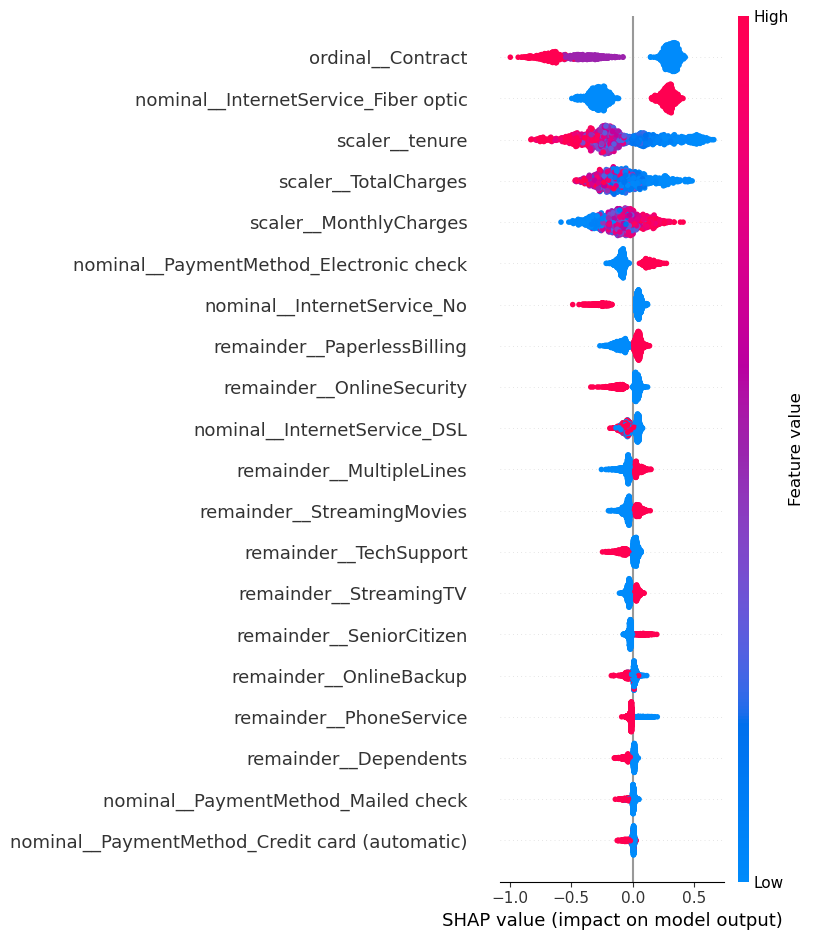

In [38]:
shap.summary_plot(shap_values, X_test_transformed_df)

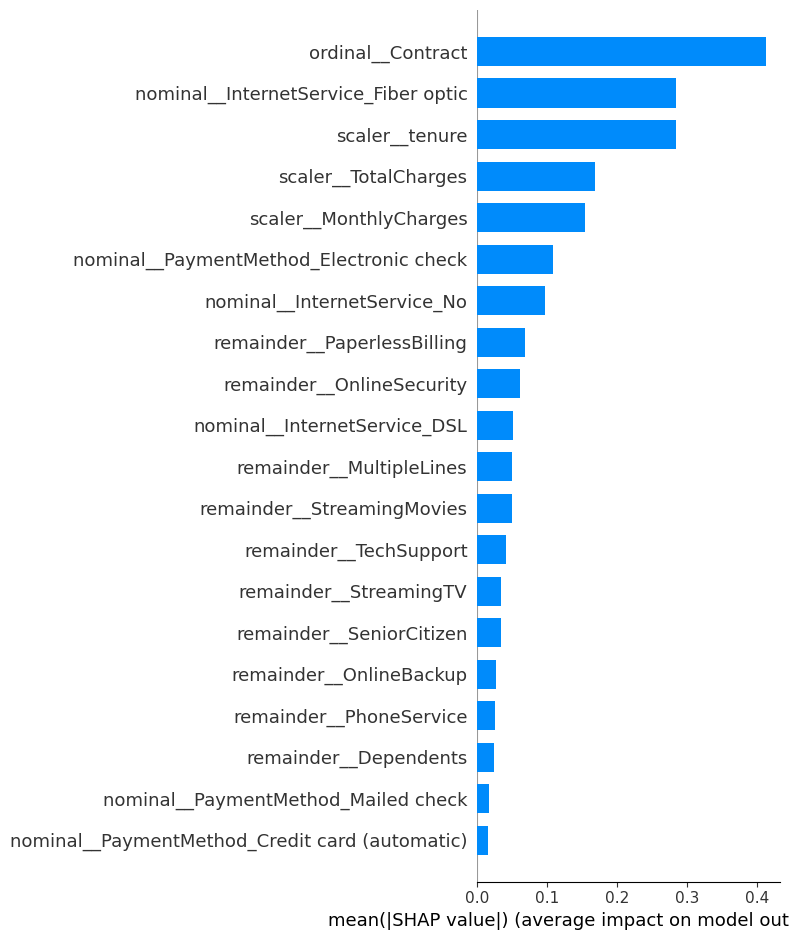

In [39]:
shap.summary_plot(shap_values, X_test_transformed_df, plot_type='bar')

In [40]:
sample_idx = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_transformed_df.iloc[sample_idx]
)

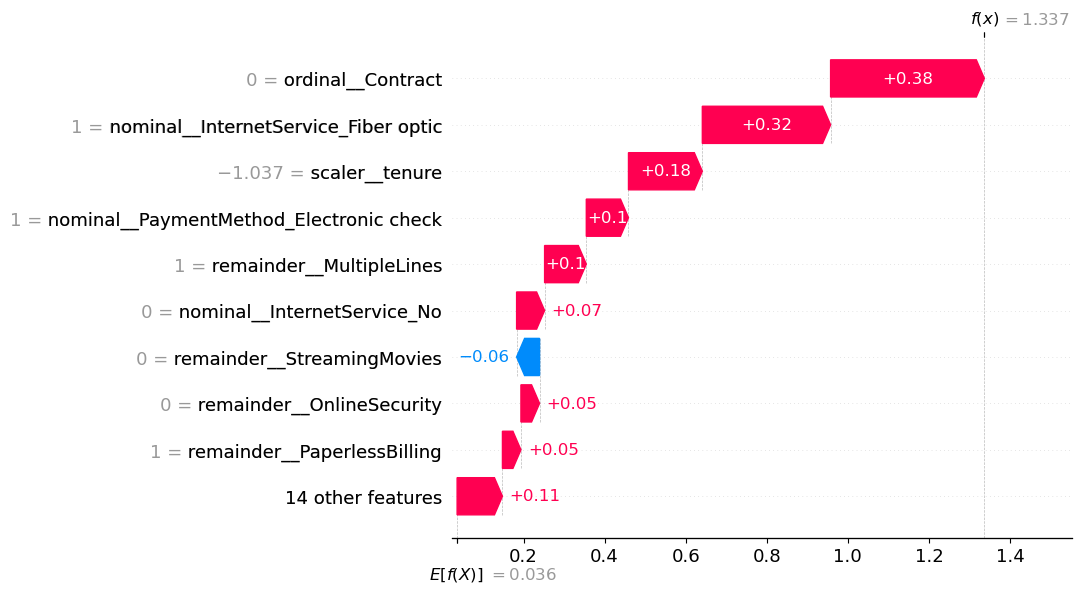

In [41]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed_df.iloc[sample_idx],
        feature_names=feature_names
    )
)

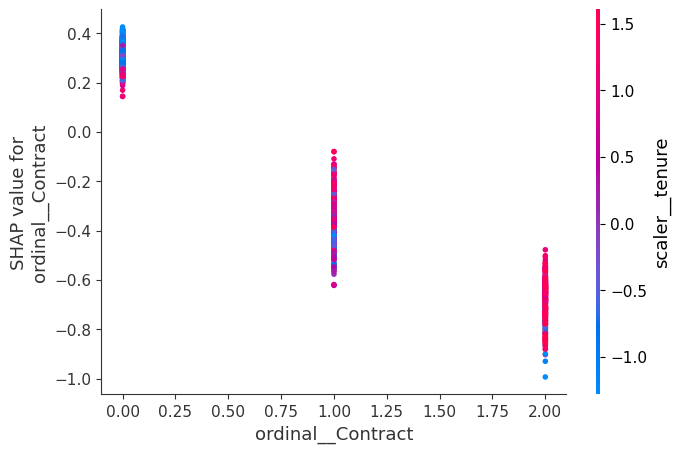

In [42]:
shap.dependence_plot('ordinal__Contract', shap_values, X_test_transformed_df, interaction_index='auto')

## SHAP Observations

 - Contract type is the #1 churn driver. Month-to-month contracts (blue) strongly push toward churn; longer contracts (One year / Two year, red) strongly push away from churn.
 - Fiber optic internet is the #2 driver. Customers with fiber optic (red) show higher churn risk, while those without it (blue) show lower risk.
 - Tenure matters a lot too. New customers (low tenure, blue) churn more; long-time customers (high tenure, red) churn less.
 - Higher total charges reduce churn, higher monthly charges increase it. These two work in opposite directions — total charges reflect loyalty/spend over time, monthly charges reflect current bill pain.
 - Electronic check payment increases churn risk. Customers paying by electronic check (red) are more likely to churn than those using other payment methods.
 - Having no internet service reduces churn risk. Customers with InternetService = No show lower churn probability — likely a lower-cost, simpler customer segment.
 - Add-on services like Online Security help retain customers. Not having these services (blue) increases churn risk.
 - Paperless billing has a small churn-increasing effect — minor but consistent.
 - Individual prediction example confirms the trend. For one customer, Month-to-month contract (+0.38), Fiber optic (+0.32), and low tenure (+0.18) were the biggest reasons the model predicted high churn risk — matching the overall top factors.
 - Contract's effect is clean and step-wise. SHAP value drops sharply as contract goes from Month-to-month → One year → Two year, meaning longer commitment consistently lowers churn risk.